In [2]:
import numpy as np


class LambdaCDMOptimizer:
    def __init__(
        self,
        objective_function,
        dim,
        bounds,
        n_agents=50,
        max_iter=500,
        gravity_growth=1.5,
        seed=None,
    ):
        self.obj = objective_function
        self.dim = dim
        self.bounds = np.array(bounds)
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.G0 = gravity_growth

        if seed:
            np.random.seed(seed)

        self.initialize_universe()

    # ---------------------------------------
    def initialize_universe(self):
        low, high = self.bounds[:, 0], self.bounds[:, 1]
        self.positions = np.random.uniform(low, high, (self.n_agents, self.dim))
        self.velocities = np.zeros_like(self.positions)
        self.fitness = np.apply_along_axis(self.obj, 1, self.positions)

    # ---------------------------------------
    def compute_gravity(self, t):
        G_t = self.G0 / (1 + t / self.max_iter)

        f_min = np.min(self.fitness)
        masses = 1 / (self.fitness - f_min + 1e-6)
        masses /= np.max(masses)

        diff = self.positions[:, None, :] - self.positions[None, :, :]
        dist = np.linalg.norm(diff, axis=2) + 1e-9
        np.fill_diagonal(dist, np.inf)

        direction = diff / dist[:, :, None]

        better = self.fitness[None, :] < self.fitness[:, None]
        weights = masses[None, :] * (0.2 + 0.8 * better)

        inv_dist_sq = 1 / (dist**2 + 1e-6)

        forces = 3 * G_t * np.sum(
            weights[:, :, None] * direction * inv_dist_sq[:, :, None],
            axis=1
        )

        return forces

    # ---------------------------------------
    def optimize(self):

        best_idx = np.argmin(self.fitness)
        global_best = self.positions[best_idx].copy()
        global_best_value = self.fitness[best_idx]

        convergence_curve = []
        diversity_curve = []

        low, high = self.bounds[:, 0], self.bounds[:, 1]

        for t in range(self.max_iter):

            # 1️⃣ Gravity
            gravity_force = self.compute_gravity(t)

            # 2️⃣ Best attraction
            best_idx = np.argmin(self.fitness)
            best_pos = self.positions[best_idx]
            exploit_force = 0.3 * (best_pos - self.positions)

            # 3️⃣ Time weighting (gravity dominates early)
            alpha = np.exp(-1 * t / self.max_iter)

            total_force = alpha * gravity_force + exploit_force

            # 4️⃣ Velocity update
            self.velocities = 0.7 * self.velocities + 0.3 * total_force
            self.velocities = np.clip(self.velocities, -0.5, 0.5)

            # 5️⃣ Position update
            self.positions += self.velocities

            # 🌌 6️⃣ ΛCDM expansion (smooth S-curve activation)
            center = np.mean(self.positions, axis=0)
            lambda_push = 1 / (1 + np.exp(-10 * (t / self.max_iter - 0.5)))

            self.positions += lambda_push * 0.15 * (self.positions - center)

            # 7️⃣ Controlled noise (exploration)
            noise_scale = max(0.02, 0.1 * (1 - t / self.max_iter))
            self.positions += np.random.normal(0, noise_scale, self.positions.shape)

            # 8️⃣ Boundary control
            self.positions = np.clip(self.positions, low, high)

            # 9️⃣ NaN guard
            self.positions = np.nan_to_num(self.positions)

            # 🔟 Fitness update
            self.fitness = np.apply_along_axis(self.obj, 1, self.positions)

            # 1️⃣1️⃣ Update global best
            best_idx = np.argmin(self.fitness)
            if self.fitness[best_idx] < global_best_value:
                global_best_value = self.fitness[best_idx]
                global_best = self.positions[best_idx].copy()

            # 1️⃣2️⃣ Track convergence
            convergence_curve.append(global_best_value)

            # 1️⃣3️⃣ Track diversity
            diversity = np.mean(np.std(self.positions, axis=0))

            # 🔥 Prevent collapse (critical fix)
            if diversity < 2.0:
                self.positions += np.random.normal(0, 0.05, self.positions.shape)
                diversity = np.mean(np.std(self.positions, axis=0))

            diversity_curve.append(diversity)

        return global_best, global_best_value, convergence_curve, diversity_curve


# ---------------------------------------
# Pressure Vessel Problem (Normalized MOO)
# ---------------------------------------
def pressure_vessel(x, w1=0.7, w2=0.3):
    x1, x2, x3, x4 = x

    f1 = (0.6224*x1*x3*x4 +
          1.7781*x2*x3**2 +
          3.1661*x1**2*x4 +
          19.84*x1**2*x3)

    f2 = np.pi * x3**2 * x4 * (x1 + x2)

    f1_norm = f1 / 10000
    f2_norm = f2 / 1e6

    penalty = 0

    if x1 - 0.0193*x3 > 0:
        penalty += 1e6 * (x1 - 0.0193*x3)

    if x2 - 0.00954*x3 > 0:
        penalty += 1e6 * (x2 - 0.00954*x3)

    if x3 + x4 - 240 > 0:
        penalty += 1e6 * (x3 + x4 - 240)

    volume = np.pi * x3**2 * x4
    if volume < 1296000:
        penalty += 1e6 * (1296000 - volume)

    return w1 * f1_norm + w2 * f2_norm + penalty


# ---------------------------------------
# RUN
# ---------------------------------------
if __name__ == "__main__":

    bounds = [
        (0.0625, 6.1875),
        (0.0625, 6.1875),
        (10, 200),
        (10, 200)
    ]

    optimizer = LambdaCDMOptimizer(
        objective_function=pressure_vessel,
        dim=4,
        bounds=bounds,
        n_agents=60,
        max_iter=500,
        seed=42
    )

    best_sol, best_fit, conv, div = optimizer.optimize()

    print("Best Solution:", best_sol)
    print("Best Fitness:", best_fit)

Best Solution: [6.25000000e-02 6.25000000e-02 4.93331540e+01 1.69645153e+02]
Best Fitness: 0.09077707828282804


In [3]:
bounds = [
    (0.0625, 6.1875),
    (0.0625, 6.1875),
    (10, 200),
    (10, 200)
]

In [4]:
import numpy as np

def pressure_vessel_moo(x, w1=0.5, w2=0.5):
    x1, x2, x3, x4 = x

    f1 = (0.6224*x1*x3*x4 +
          1.7781*x2*x3**2 +
          3.1661*x1**2*x4 +
          19.84*x1**2*x3)

    f2 = np.pi * x3**2 * x4 * (x1 + x2)

    #  Normalize (approx ranges)
    f1_norm = f1 / 10000
    f2_norm = f2 / 1e6

    penalty = 0

    if x1 - 0.0193*x3 > 0:
        penalty += 1e6 * (x1 - 0.0193*x3)

    if x2 - 0.00954*x3 > 0:
        penalty += 1e6 * (x2 - 0.00954*x3)

    if x3 + x4 - 240 > 0:
        penalty += 1e6 * (x3 + x4 - 240)

    volume = np.pi * x3**2 * x4
    if volume < 1296000:
        penalty += 1e6 * (1296000 - volume)

    return w1*f1_norm + w2*f2_norm + penalty

In [5]:
optimizer = LambdaCDMOptimizer(
    objective_function=lambda x: pressure_vessel_moo(x, 0.7, 0.3),
    dim=4,
    bounds=bounds,
    n_agents=60,
    max_iter=500,
    seed=42
)

best_sol, best_fit, conv, div = optimizer.optimize()

print("Best Solution:", best_sol)
print("Best Fitness:", best_fit)

Best Solution: [6.25000000e-02 6.25000000e-02 4.93331540e+01 1.69645153e+02]
Best Fitness: 0.09077707828282804


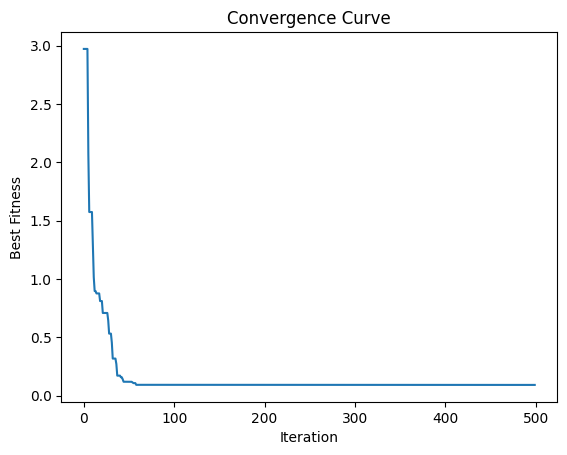

In [6]:
# Plot convergence plot
import matplotlib.pyplot as plt

plt.plot(conv)
plt.title("Convergence Curve")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.show()


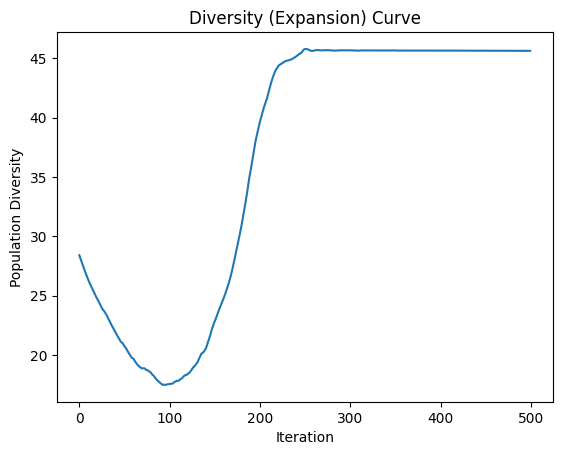

In [7]:
plt.plot(div)
plt.title("Diversity (Expansion) Curve")
plt.xlabel("Iteration")
plt.ylabel("Population Diversity")
plt.show()

In [8]:
# PSO (simple version)
from pyswarm import pso

best_pso, val_pso = pso(
    pressure_vessel,
    lb=[0.0625,0.0625,10,10],
    ub=[6.1875,6.1875,200,200]
)

print("PSO:", val_pso)

# Your ΛCDM
best_lcdm, val_lcdm, _, _ = optimizer.optimize()


Stopping search: Swarm best objective change less than 1e-08
PSO: 0.09498313936833197
